# 🧠 LeJEPA sur MedMNIST : Apprentissage auto-supervisé pour l'imagerie médicale

Ce notebook implémente **LeJEPA** (Latent-Euclidean Joint-Embedding Predictive Architecture) avec la régularisation **SIGReg** pour apprendre des représentations à partir d'images médicales **sans aucun label**.

### Ce que vous allez faire :
1. **Installer** les dépendances et télécharger MedMNIST
2. **Implémenter** la perte SIGReg (Sketched Isotropic Gaussian Regularization)
3. **Construire** un encodeur Vision Transformer léger + prédicteur JEPA
4. **Entraîner** le modèle en auto-supervisé (multi-crop, sans labels)
5. **Évaluer** la qualité des représentations via sonde linéaire
6. **Visualiser** l'espace latent (t-SNE, PCA)

### Ressources requises :
- **GPU** : 1× RTX 3060+ (ou Google Colab)
- **Disque** : ~500 Mo (MedMNIST 28×28)
- **Temps d'entraînement** : ~30-60 min selon le GPU

### Références :
- [LeJEPA (arXiv 2511.08544)](https://arxiv.org/abs/2511.08544) — Balestriero & LeCun, 2025
- [LeWorldModel (arXiv 2603.19312)](https://le-wm.github.io/) — Maes, Le Lidec et al., 2026
- [MedMNIST v2 (Scientific Data)](https://medmnist.com/) — Yang et al., 2023

## 1. Installation et imports

In [1]:
# Installation des dépendances
# Décommentez si nécessaire (Colab, environnement frais)
# !pip install medmnist timm torch torchvision matplotlib scikit-learn tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as T

import medmnist
from medmnist import INFO

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm
import os

# Configuration du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
VRAM: 8.2 GB


## 2. Configuration

Choisissez votre sous-dataset MedMNIST. Recommandations pour commencer :
- **`pathmnist`** : ~100K images de pathologie colorectale (9 classes) — le plus gros, bon pour le SSL
- **`dermamnist`** : ~10K images dermatoscopiques (7 classes) — pertinent cliniquement
- **`bloodmnist`** : ~17K images de cellules sanguines (8 classes) — bon compromis taille/variété
- **`retinamnist`** : ~1 600 images rétiniennes (5 classes) — petit mais intéressant

In [3]:
# ==================== CONFIGURATION ====================

# Dataset MedMNIST
DATASET_NAME = "dermamnist"          # Changer ici pour tester d'autres datasets
IMAGE_SIZE = 28                      # 28 pour commencer (64, 128, 224 pour MedMNIST+)

# Architecture
EMBED_DIM = 192                      # Dimension de l'espace latent (comme LeWorldModel)
PATCH_SIZE = 4                       # Taille des patches pour le ViT (28/4 = 7×7 = 49 patches)
NUM_HEADS = 6                        # Nombre de têtes d'attention
NUM_LAYERS = 4                       # Nombre de couches Transformer
PREDICTOR_DEPTH = 2                  # Profondeur du prédicteur MLP

# Entraînement
BATCH_SIZE = 256                     # Réduire à 128 si OOM
NUM_EPOCHS = 50                      # 50 epochs suffisent pour MedMNIST-28
LEARNING_RATE = 1e-3                 # Taux d'apprentissage (Adam)
WEIGHT_DECAY = 1e-4                  # Régularisation L2
LAMBDA_SIGREG = 1.0                  # Poids du terme SIGReg (λ)

# SIGReg
NUM_SLICES = 512                     # Nombre de projections aléatoires
NUM_T_POINTS = 17                    # Points d'intégration pour Epps-Pulley

# Multi-crop (inspiré de DINO/LeJEPA)
NUM_GLOBAL_CROPS = 2                 # Vues globales
NUM_LOCAL_CROPS = 4                  # Vues locales
GLOBAL_CROP_SCALE = (0.6, 1.0)      # Échelle des crops globaux
LOCAL_CROP_SCALE = (0.2, 0.5)        # Échelle des crops locaux

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Dataset: {DATASET_NAME} ({IMAGE_SIZE}×{IMAGE_SIZE})")
print(f"Embedding dim: {EMBED_DIM}")
print(f"Epochs: {NUM_EPOCHS}, Batch size: {BATCH_SIZE}")
print(f"λ_SIGReg: {LAMBDA_SIGREG}")

Dataset: dermamnist (28×28)
Embedding dim: 192
Epochs: 50, Batch size: 256
λ_SIGReg: 1.0


## 3. Chargement des données MedMNIST

In [4]:
# Informations sur le dataset
info = INFO[DATASET_NAME]
n_channels = info["n_channels"]
n_classes = len(info["label"])
DataClass = getattr(medmnist, info["python_class"])

print(f"Nom: {info['python_class']}")
print(f"Canaux: {n_channels}, Classes: {n_classes}")
print(f"Tâche: {info['task']}")
print(f"Description: {info['description'][:200]}...")

Nom: DermaMNIST
Canaux: 3, Classes: 7
Tâche: multi-class
Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 ...


In [5]:
# === Transformations pour l'entraînement auto-supervisé (multi-crop) ===

# Augmentations communes
color_jitter = T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)

def make_crop_transform(crop_scale, output_size=IMAGE_SIZE):
    """Crée une transformation de crop aléatoire avec augmentations."""
    return T.Compose([
        T.RandomResizedCrop(output_size, scale=crop_scale, interpolation=T.InterpolationMode.BICUBIC),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),           # Utile en imagerie médicale
        T.RandomApply([color_jitter], p=0.8),
        T.RandomGrayscale(p=0.2),
        T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.3),
        T.ToTensor(),
        T.Normalize(mean=[0.5] * 3, std=[0.5] * 3),  # Normalisation [-1, 1]
    ])

global_transform = make_crop_transform(GLOBAL_CROP_SCALE)
local_transform = make_crop_transform(LOCAL_CROP_SCALE)

# Transform simple pour l'évaluation (pas d'augmentation)
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5] * 3, std=[0.5] * 3),
])


class MultiCropDataset(torch.utils.data.Dataset):
    """Wrapper qui génère plusieurs vues (crops) de chaque image.
    
    Inspiré de la stratégie multi-crop de DINO et LeJEPA :
    - Les vues globales capturent la sémantique de haut niveau
    - Les vues locales encouragent l'apprentissage de features fines
    """
    def __init__(self, base_dataset, n_global=2, n_local=4):
        self.base_dataset = base_dataset
        self.n_global = n_global
        self.n_local = n_local
    
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        # img est un PIL Image grâce à MedMNIST (quand on ne passe pas de transform)
        
        crops = []
        for _ in range(self.n_global):
            crops.append(global_transform(img))
        for _ in range(self.n_local):
            crops.append(local_transform(img))
        
        return crops, label

In [6]:
# Téléchargement et chargement des datasets
# Note: on passe as_rgb=True pour uniformiser les canaux

# Dataset d'entraînement SANS transform (le MultiCropDataset gère les augmentations)
train_dataset_raw = DataClass(split="train", download=True, as_rgb=True, size=IMAGE_SIZE)
val_dataset_raw = DataClass(split="val", download=True, as_rgb=True, size=IMAGE_SIZE)
test_dataset_raw = DataClass(split="test", download=True, as_rgb=True, size=IMAGE_SIZE)

# Dataset multi-crop pour l'entraînement SSL
train_ssl = MultiCropDataset(train_dataset_raw, n_global=NUM_GLOBAL_CROPS, n_local=NUM_LOCAL_CROPS)

# Datasets avec transform simple pour l'évaluation
train_eval = DataClass(split="train", transform=eval_transform, download=True, as_rgb=True, size=IMAGE_SIZE)
val_eval = DataClass(split="val", transform=eval_transform, download=True, as_rgb=True, size=IMAGE_SIZE)
test_eval = DataClass(split="test", transform=eval_transform, download=True, as_rgb=True, size=IMAGE_SIZE)

# DataLoaders
# DataLoaders — num_workers=0 pour éviter les erreurs multiprocessing dans Jupyter
train_ssl_loader = DataLoader(train_ssl, batch_size=BATCH_SIZE, shuffle=True, 
                               num_workers=0, pin_memory=True, drop_last=True)
train_eval_loader = DataLoader(train_eval, batch_size=512, shuffle=False, num_workers=0)
val_eval_loader = DataLoader(val_eval, batch_size=512, shuffle=False, num_workers=0)
test_eval_loader = DataLoader(test_eval, batch_size=512, shuffle=False, num_workers=0)

print(f"\nTailles des datasets:")
print(f"  Train: {len(train_dataset_raw)} images")
print(f"  Val:   {len(val_dataset_raw)} images")
print(f"  Test:  {len(test_dataset_raw)} images")


Tailles des datasets:
  Train: 7007 images
  Val:   1003 images
  Test:  2005 images


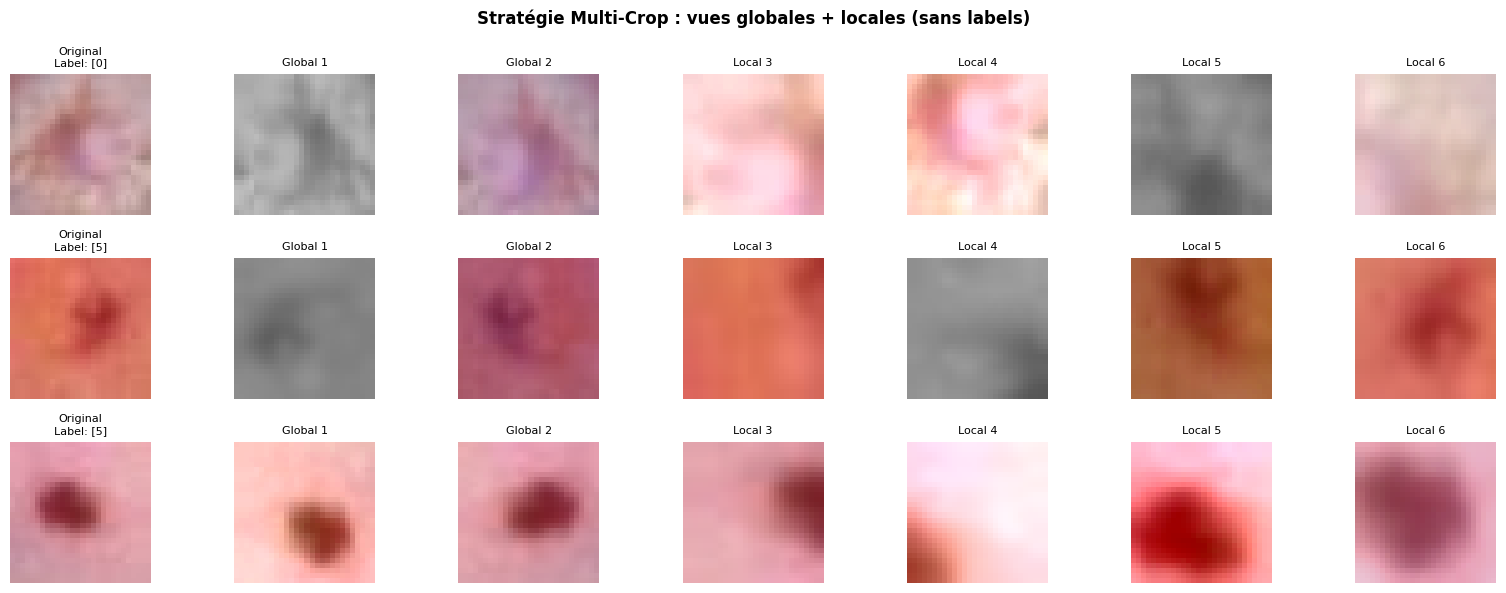

In [7]:
# Visualisation de quelques exemples + leurs augmentations multi-crop
fig, axes = plt.subplots(3, NUM_GLOBAL_CROPS + NUM_LOCAL_CROPS + 1, figsize=(16, 6))

for row in range(3):
    crops, label = train_ssl[row]
    img_orig, _ = train_dataset_raw[row]
    
    # Image originale
    axes[row, 0].imshow(img_orig)
    axes[row, 0].set_title(f"Original\nLabel: {label}", fontsize=8)
    axes[row, 0].axis("off")
    
    # Crops augmentés
    for i, crop in enumerate(crops):
        img = crop.permute(1, 2, 0).numpy() * 0.5 + 0.5  # Dé-normalisation
        img = np.clip(img, 0, 1)
        crop_type = "Global" if i < NUM_GLOBAL_CROPS else "Local"
        axes[row, i + 1].imshow(img)
        axes[row, i + 1].set_title(f"{crop_type} {i+1}", fontsize=8)
        axes[row, i + 1].axis("off")

plt.suptitle("Stratégie Multi-Crop : vues globales + locales (sans labels)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Implémentation de SIGReg

**SIGReg** (Sketched Isotropic Gaussian Regularization) est le cœur théorique de LeJEPA.

L'idée : forcer les embeddings à suivre une distribution **gaussienne isotrope** $\mathcal{N}(0, I_D)$, qui est prouvée comme la distribution optimale minimisant le risque de prédiction en aval.

Le mécanisme :
1. **Projection aléatoire** : projeter les embeddings sur $M$ directions aléatoires de la sphère unitaire
2. **Test d'Epps-Pulley** : comparer chaque projection 1D à une distribution $\mathcal{N}(0, 1)$
3. **Théorème de Cramér-Wold** : si toutes les projections 1D sont gaussiennes → la distribution multivariée l'est aussi

In [8]:
class SIGReg(nn.Module):
    """Sketched Isotropic Gaussian Regularization.
    
    Implémentation fidèle basée sur LeJEPA (Balestriero & LeCun, 2025).
    Utilise le test d'Epps-Pulley via la fonction caractéristique empirique.
    
    Complexité : O(N × D × M) au lieu de O(N × D²) pour la covariance complète.
    
    Args:
        num_slices: Nombre de projections aléatoires (M)
        num_t_points: Points d'intégration pour le test d'Epps-Pulley
    """
    def __init__(self, num_slices=512, num_t_points=17):
        super().__init__()
        self.num_slices = num_slices
        self.num_t_points = num_t_points
        
        # Points d'intégration pour Epps-Pulley (fixés)
        t = torch.linspace(-5.0, 5.0, num_t_points)
        self.register_buffer("t_points", t)
    
    def _epps_pulley_1d(self, x_1d):
        """Test d'Epps-Pulley pour une projection 1D.
        
        Compare la fonction caractéristique empirique (ECF) des données
        à celle d'une gaussienne N(0,1).
        
        ECF empirique : φ_n(t) = (1/n) Σ exp(i·t·x_j)
        ECF gaussienne : φ(t) = exp(-t²/2)
        
        La perte est ||φ_n(t) - φ(t)||² intégrée sur les points t.
        
        Args:
            x_1d: Tensor [N] — données projetées sur une direction
        Returns:
            Scalaire — divergence par rapport à N(0,1)
        """
        N = x_1d.shape[0]
        t = self.t_points  # [T]
        
        # Standardiser les données (centrer et réduire)
        x_centered = x_1d - x_1d.mean()
        x_std = x_centered.std() + 1e-8
        x_norm = x_centered / x_std
        
        # Fonction caractéristique empirique : φ_n(t) = (1/N) Σ_j exp(i·t·x_j)
        # On calcule les parties réelle et imaginaire séparément
        # tx = t[T] × x[N] → [T, N]
        tx = t.unsqueeze(1) * x_norm.unsqueeze(0)  # [T, N]
        
        ecf_real = torch.cos(tx).mean(dim=1)  # [T] — partie réelle de φ_n(t)
        ecf_imag = torch.sin(tx).mean(dim=1)  # [T] — partie imaginaire de φ_n(t)
        
        # Fonction caractéristique de N(0,1) : φ(t) = exp(-t²/2)
        gauss_cf = torch.exp(-0.5 * t ** 2)  # [T]
        
        # Distance L² entre ECF empirique et ECF gaussienne
        # |φ_n(t) - φ(t)|² = (Re(φ_n) - φ)² + Im(φ_n)²
        diff_real = ecf_real - gauss_cf
        diff_imag = ecf_imag  # La partie imaginaire de φ(t) est 0 pour N(0,1)
        
        loss = (diff_real ** 2 + diff_imag ** 2).mean()
        
        # Terme additionnel : pénaliser l'écart de la variance par rapport à 1
        var_penalty = (x_std - 1.0) ** 2
        
        return loss + var_penalty
    
    def forward(self, embeddings):
        """Calcule la perte SIGReg sur un batch d'embeddings.
        
        Args:
            embeddings: Tensor [N, D] — embeddings du batch
        Returns:
            Scalaire — perte SIGReg (plus petite = plus proche de N(0, I_D))
        """
        N, D = embeddings.shape
        
        # Générer M directions aléatoires sur la sphère unitaire
        # A ∈ R^{D × M}, normalisé par colonne
        A = torch.randn(D, self.num_slices, device=embeddings.device)
        A = F.normalize(A, p=2, dim=0)  # [D, M]
        
        # Projeter les embeddings : Z_proj = embeddings @ A → [N, M]
        projections = embeddings @ A  # [N, M]
        
        # Appliquer le test d'Epps-Pulley sur chaque projection
        total_loss = 0.0
        for m in range(self.num_slices):
            total_loss = total_loss + self._epps_pulley_1d(projections[:, m])
        
        return total_loss / self.num_slices


# Version vectorisée plus rapide pour l'entraînement
class SIGRegFast(nn.Module):
    """Version vectorisée et optimisée de SIGReg.
    
    Même principe mathématique, mais calcule toutes les projections
    en parallèle pour exploiter le parallélisme GPU.
    """
    def __init__(self, num_slices=512, num_t_points=17):
        super().__init__()
        self.num_slices = num_slices
        t = torch.linspace(-5.0, 5.0, num_t_points)
        self.register_buffer("t_points", t)
    
    def forward(self, embeddings):
        N, D = embeddings.shape
        
        # Directions aléatoires normalisées [D, M]
        A = torch.randn(D, self.num_slices, device=embeddings.device, dtype=embeddings.dtype)
        A = F.normalize(A, p=2, dim=0)
        
        # Projections [N, M]
        proj = embeddings @ A
        
        # Standardiser chaque projection
        proj_mean = proj.mean(dim=0, keepdim=True)     # [1, M]
        proj_centered = proj - proj_mean
        proj_std = proj_centered.std(dim=0, keepdim=True) + 1e-8  # [1, M]
        proj_norm = proj_centered / proj_std            # [N, M]
        
        # ECF empirique vectorisée
        # t_points [T] × proj_norm [N, M] → [T, N, M]
        t = self.t_points[:, None, None]                # [T, 1, 1]
        tx = t * proj_norm.unsqueeze(0)                 # [T, N, M]
        
        ecf_real = torch.cos(tx).mean(dim=1)            # [T, M]
        ecf_imag = torch.sin(tx).mean(dim=1)            # [T, M]
        
        # ECF de N(0,1)
        gauss_cf = torch.exp(-0.5 * self.t_points ** 2)[:, None]  # [T, 1]
        
        # Perte par projection
        loss = ((ecf_real - gauss_cf) ** 2 + ecf_imag ** 2).mean()
        
        # Pénalité de variance
        var_penalty = ((proj_std.squeeze() - 1.0) ** 2).mean()
        
        return loss + var_penalty


# Test rapide
sigreg_test = SIGRegFast(num_slices=256, num_t_points=17).to(device)
z_random = torch.randn(64, EMBED_DIM, device=device)  # Déjà gaussien
z_collapsed = torch.ones(64, EMBED_DIM, device=device) * 0.5  # Effondré

print(f"SIGReg(gaussien)  = {sigreg_test(z_random).item():.4f}  (devrait être ~0)")
print(f"SIGReg(effondré)  = {sigreg_test(z_collapsed).item():.4f}  (devrait être >> 0)")

SIGReg(gaussien)  = 0.0199  (devrait être ~0)
SIGReg(effondré)  = 1.6950  (devrait être >> 0)


## 5. Architecture : Encodeur ViT + Prédicteur JEPA

L'architecture suit le principe de LeJEPA/LeWorldModel :
- **Encodeur** : un petit Vision Transformer qui transforme une image en un unique vecteur de `EMBED_DIM` dimensions
- **Prédicteur** : un MLP qui prédit l'embedding d'une vue cible à partir d'une vue contexte

Pas de teacher-student, pas d'EMA, pas de stop-gradient — juste SIGReg.

In [9]:
class PatchEmbedding(nn.Module):
    """Découpe l'image en patches et les projette en embeddings."""
    def __init__(self, img_size=28, patch_size=4, in_channels=3, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, 
                             kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        # x: [B, C, H, W] → [B, D, H', W'] → [B, N_patches, D]
        x = self.proj(x)                    # [B, D, H/P, W/P]
        x = x.flatten(2).transpose(1, 2)    # [B, N_patches, D]
        return x


class TransformerBlock(nn.Module):
    """Bloc Transformer standard (pre-norm)."""
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout),
        )
    
    def forward(self, x):
        # Pre-norm architecture
        x_norm = self.norm1(x)
        x = x + self.attn(x_norm, x_norm, x_norm, need_weights=False)[0]
        x = x + self.mlp(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    """Vision Transformer léger pour MedMNIST.
    
    Produit un unique vecteur de dimension `embed_dim` par image,
    via le token [CLS] — comme dans LeWorldModel.
    """
    def __init__(self, img_size=28, patch_size=4, in_channels=3,
                 embed_dim=192, num_heads=6, num_layers=4, dropout=0.0):
        super().__init__()
        self.embed_dim = embed_dim
        
        # Patch embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        # Token [CLS] et embeddings positionnels
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        
        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x):
        """Encode une image en un vecteur latent unique.
        
        Args:
            x: [B, C, H, W] — batch d'images
        Returns:
            [B, embed_dim] — embeddings (via le token [CLS])
        """
        B = x.shape[0]
        
        # Patch embedding + CLS token
        x = self.patch_embed(x)                                    # [B, N, D]
        cls = self.cls_token.expand(B, -1, -1)                     # [B, 1, D]
        x = torch.cat([cls, x], dim=1)                             # [B, N+1, D]
        x = x + self.pos_embed                                     # + positional
        
        # Transformer
        for block in self.blocks:
            x = block(x)
        
        x = self.norm(x)
        return x[:, 0]  # Retourne uniquement le token [CLS] → [B, D]


class JEPAPredictor(nn.Module):
    """Prédicteur JEPA : prédit l'embedding d'une vue cible à partir d'une vue contexte.
    
    Simple MLP, car la prédiction se fait dans l'espace latent (pas pixel-space).
    """
    def __init__(self, embed_dim=192, hidden_dim=384, depth=2):
        super().__init__()
        layers = []
        in_dim = embed_dim
        for i in range(depth):
            out_dim = hidden_dim if i < depth - 1 else embed_dim
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.LayerNorm(out_dim),
                nn.GELU() if i < depth - 1 else nn.Identity(),
            ])
            in_dim = out_dim
        self.net = nn.Sequential(*layers)
    
    def forward(self, z_context):
        """Prédit l'embedding cible à partir de l'embedding contexte."""
        return self.net(z_context)


class LeJEPAModel(nn.Module):
    """Modèle LeJEPA complet : Encodeur + Prédicteur + SIGReg.
    
    Perte totale : L = L_pred + λ · SIGReg(Z)
    
    Où :
    - L_pred = MSE entre la prédiction et l'embedding cible
    - SIGReg(Z) = régularisation gaussienne isotrope sur les embeddings
    """
    def __init__(self, img_size=28, patch_size=4, in_channels=3,
                 embed_dim=192, num_heads=6, num_layers=4,
                 predictor_depth=2, num_slices=512, num_t_points=17):
        super().__init__()
        
        self.encoder = ViTEncoder(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels,
            embed_dim=embed_dim, num_heads=num_heads, num_layers=num_layers
        )
        self.predictor = JEPAPredictor(
            embed_dim=embed_dim, hidden_dim=embed_dim * 2, depth=predictor_depth
        )
        self.sigreg = SIGRegFast(num_slices=num_slices, num_t_points=num_t_points)
    
    def encode(self, x):
        """Encode une image en embedding latent."""
        return self.encoder(x)
    
    def forward(self, crops, lambda_sigreg=1.0):
        """Calcule la perte LeJEPA sur un batch de multi-crops.
        
        Args:
            crops: liste de tenseurs [B, C, H, W] — vues globales puis locales
            lambda_sigreg: poids du terme SIGReg
        
        Returns:
            total_loss, pred_loss, sigreg_loss
        """
        # Encoder toutes les vues
        all_embeddings = [self.encoder(crop) for crop in crops]  # liste de [B, D]
        
        # Perte de prédiction : chaque vue globale prédit chaque autre vue
        pred_loss = 0.0
        n_pairs = 0
        n_global = NUM_GLOBAL_CROPS
        
        for i in range(n_global):
            z_context = all_embeddings[i]             # Vue globale comme contexte
            z_pred = self.predictor(z_context)         # Prédiction
            
            for j in range(len(all_embeddings)):
                if i != j:
                    z_target = all_embeddings[j].detach()  # Target (sans gradient ici)
                    pred_loss = pred_loss + F.mse_loss(z_pred, z_target)
                    n_pairs += 1
        
        pred_loss = pred_loss / n_pairs
        
        # SIGReg sur l'ensemble des embeddings concaténés
        all_z = torch.cat(all_embeddings, dim=0)  # [B × num_views, D]
        sigreg_loss = self.sigreg(all_z)
        
        # Perte totale
        total_loss = pred_loss + lambda_sigreg * sigreg_loss
        
        return total_loss, pred_loss, sigreg_loss


# Instanciation du modèle
model = LeJEPAModel(
    img_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=3,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    predictor_depth=PREDICTOR_DEPTH,
    num_slices=NUM_SLICES,
    num_t_points=NUM_T_POINTS,
).to(device)

# Compter les paramètres
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Modèle LeJEPA créé:")
print(f"   Paramètres totaux: {n_params:,} ({n_params/1e6:.2f}M)")
print(f"   Encodeur: {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"   Prédicteur: {sum(p.numel() for p in model.predictor.parameters()):,}")
print(f"   Embedding dim: {EMBED_DIM}")


📊 Modèle LeJEPA créé:
   Paramètres totaux: 1,948,224 (1.95M)
   Encodeur: 1,799,040
   Prédicteur: 149,184
   Embedding dim: 192


## 6. Boucle d'entraînement auto-supervisé

L'entraînement est **entièrement auto-supervisé** : aucun label n'est utilisé.

La perte est : **L = L_pred + λ · SIGReg(Z)**

In [10]:
# Optimiseur
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Scheduler cosine
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# Historique pour le monitoring
history = {
    "total_loss": [], "pred_loss": [], "sigreg_loss": [], "lr": []
}

In [11]:
print("🚀 Entraînement auto-supervisé LeJEPA sur MedMNIST")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_total, epoch_pred, epoch_sig = 0.0, 0.0, 0.0
    n_batches = 0
    
    pbar = tqdm(train_ssl_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    
    for crops_batch, _ in pbar:  # On ignore les labels !
        # Déplacer les crops sur GPU
        crops = [c.to(device) for c in crops_batch]
        
        # Forward
        total_loss, pred_loss, sigreg_loss = model(crops, lambda_sigreg=LAMBDA_SIGREG)
        
        # Backward
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Accumulation
        epoch_total += total_loss.item()
        epoch_pred += pred_loss.item()
        epoch_sig += sigreg_loss.item()
        n_batches += 1
        
        pbar.set_postfix({
            "L_total": f"{total_loss.item():.4f}",
            "L_pred": f"{pred_loss.item():.4f}",
            "SIGReg": f"{sigreg_loss.item():.4f}",
        })
    
    scheduler.step()
    
    # Moyennes de l'epoch
    avg_total = epoch_total / n_batches
    avg_pred = epoch_pred / n_batches
    avg_sig = epoch_sig / n_batches
    
    history["total_loss"].append(avg_total)
    history["pred_loss"].append(avg_pred)
    history["sigreg_loss"].append(avg_sig)
    history["lr"].append(optimizer.param_groups[0]["lr"])
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Total: {avg_total:.4f} | Pred: {avg_pred:.4f} | "
              f"SIGReg: {avg_sig:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

print("\n✅ Entraînement terminé !")

🚀 Entraînement auto-supervisé LeJEPA sur MedMNIST


Epoch 1/50:   0%|          | 0/27 [00:00<?, ?it/s]

  Epoch   1/50 | Total: 1.2537 | Pred: 1.0574 | SIGReg: 0.1963 | LR: 9.99e-04


Epoch 2/50:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/27 [00:00<?, ?it/s]

...

Epoch 47/50:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/27 [00:00<?, ?it/s]

  Epoch  50/50 | Total: 0.8916 | Pred: 0.8369 | SIGReg: 0.0547 | LR: 1.00e-06

✅ Entraînement terminé !


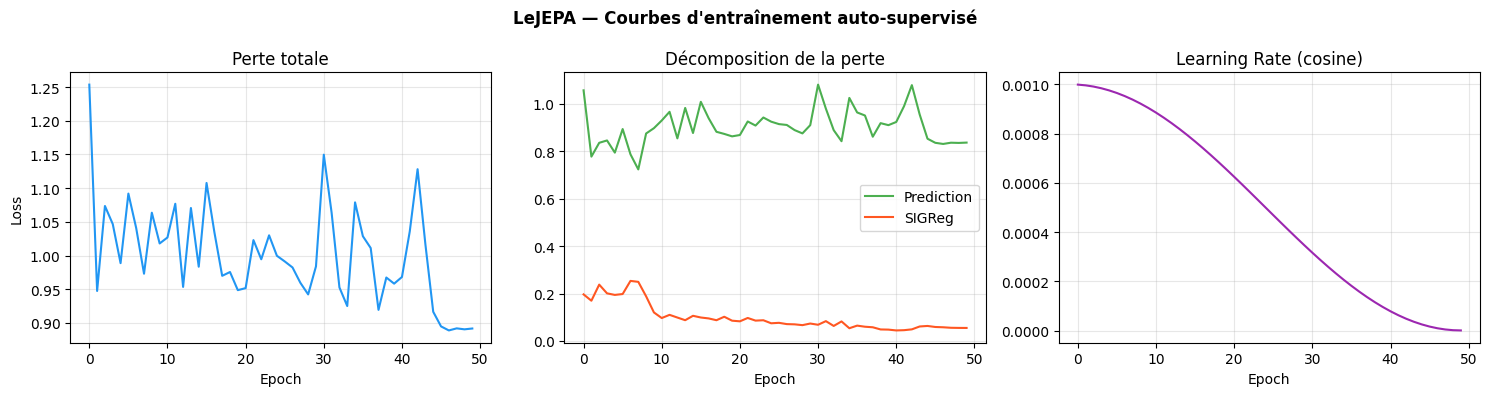

In [12]:
# Courbes d'entraînement
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["total_loss"], label="Total Loss", color="#2196F3")
axes[0].set_title("Perte totale")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["pred_loss"], label="Prediction", color="#4CAF50")
axes[1].plot(history["sigreg_loss"], label="SIGReg", color="#FF5722")
axes[1].set_title("Décomposition de la perte")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history["lr"], color="#9C27B0")
axes[2].set_title("Learning Rate (cosine)")
axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.3)

plt.suptitle("LeJEPA — Courbes d'entraînement auto-supervisé", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Évaluation par sonde linéaire (Linear Probing)

C'est le moment de vérité : on gèle l'encodeur et on entraîne un **simple classifieur linéaire** par-dessus.

Si les représentations apprises par LeJEPA sont bonnes, même une régression logistique devrait obtenir de bonnes performances. C'est le protocole standard d'évaluation en apprentissage auto-supervisé.

In [13]:
@torch.no_grad()
def extract_features(model, dataloader, device):
    """Extrait les features de l'encodeur gelé pour tout un dataset."""
    model.eval()
    all_features = []
    all_labels = []
    
    for images, labels in tqdm(dataloader, desc="Extraction", leave=False):
        images = images.to(device)
        features = model.encode(images)  # [B, D]
        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())
    
    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0).flatten()
    return features, labels


print("📊 Extraction des features...")
train_features, train_labels = extract_features(model, train_eval_loader, device)
val_features, val_labels = extract_features(model, val_eval_loader, device)
test_features, test_labels = extract_features(model, test_eval_loader, device)

print(f"   Train: {train_features.shape}")
print(f"   Val:   {val_features.shape}")
print(f"   Test:  {test_features.shape}")

📊 Extraction des features...


Extraction:   0%|          | 0/14 [00:00<?, ?it/s]

Extraction:   0%|          | 0/2 [00:00<?, ?it/s]

Extraction:   0%|          | 0/4 [00:00<?, ?it/s]

   Train: (7007, 192)
   Val:   (1003, 192)
   Test:  (2005, 192)


In [21]:
from sklearn.preprocessing import StandardScaler
# Sonde linéaire avec scikit-learn (régression logistique)
print("\n🔬 Entraînement de la sonde linéaire...")

# Tester plusieurs régularisations
best_val_acc = 0
best_C = 1.0


# Normaliser les features avant le linear probing
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
val_features_scaled = scaler.transform(val_features)
test_features_scaled = scaler.transform(test_features)

for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    clf = LogisticRegression(
        C=C, max_iter=5000, solver="lbfgs", n_jobs=-1
    )
    clf.fit(train_features_scaled, train_labels)
    val_acc = accuracy_score(val_labels, clf.predict(val_features_scaled))
    print(f"   C={C:6.2f} → Val Accuracy: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_C = C

# Entraîner avec le meilleur C
print(f"\n✅ Meilleur C: {best_C} (Val Acc: {best_val_acc:.4f})")
clf_best = LogisticRegression(
    C=best_C, max_iter=5000, solver="lbfgs", n_jobs=-1
)
clf_best.fit(train_features, train_labels)

# Évaluation finale sur le test set
test_preds = clf_best.predict(test_features)
test_acc = accuracy_score(test_labels, test_preds)

print(f"\n🎯 TEST ACCURACY (sonde linéaire): {test_acc:.4f} ({test_acc*100:.1f}%)")
print("\n" + classification_report(
    test_labels, test_preds, 
    target_names=[str(v) for v in info["label"].values()]
))


🔬 Entraînement de la sonde linéaire...
   C=  0.01 → Val Accuracy: 0.6830
   C=  0.10 → Val Accuracy: 0.6939
   C=  1.00 → Val Accuracy: 0.7009
   C= 10.00 → Val Accuracy: 0.6969
   C=100.00 → Val Accuracy: 0.6909

✅ Meilleur C: 1.0 (Val Acc: 0.7009)

🎯 TEST ACCURACY (sonde linéaire): 0.6903 (69.0%)

                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.19      0.08      0.11        66
                           basal cell carcinoma       0.34      0.27      0.30       103
                  benign keratosis-like lesions       0.47      0.27      0.34       220
                                 dermatofibroma       0.00      0.00      0.00        23
                                       melanoma       0.42      0.13      0.20       223
                               melanocytic nevi       0.74      0.93      0.83      1341
                               vascular lesions       0.69      0.38     

/home/dakoro/Github/ai-experiments/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dakoro/Github/ai-experiments/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dakoro/Github/ai-experiments/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

## 8. Visualisation de l'espace latent

Visualisons les embeddings appris pour vérifier que SIGReg structure bien l'espace latent.

Computing t-SNE...
Computing PCA...


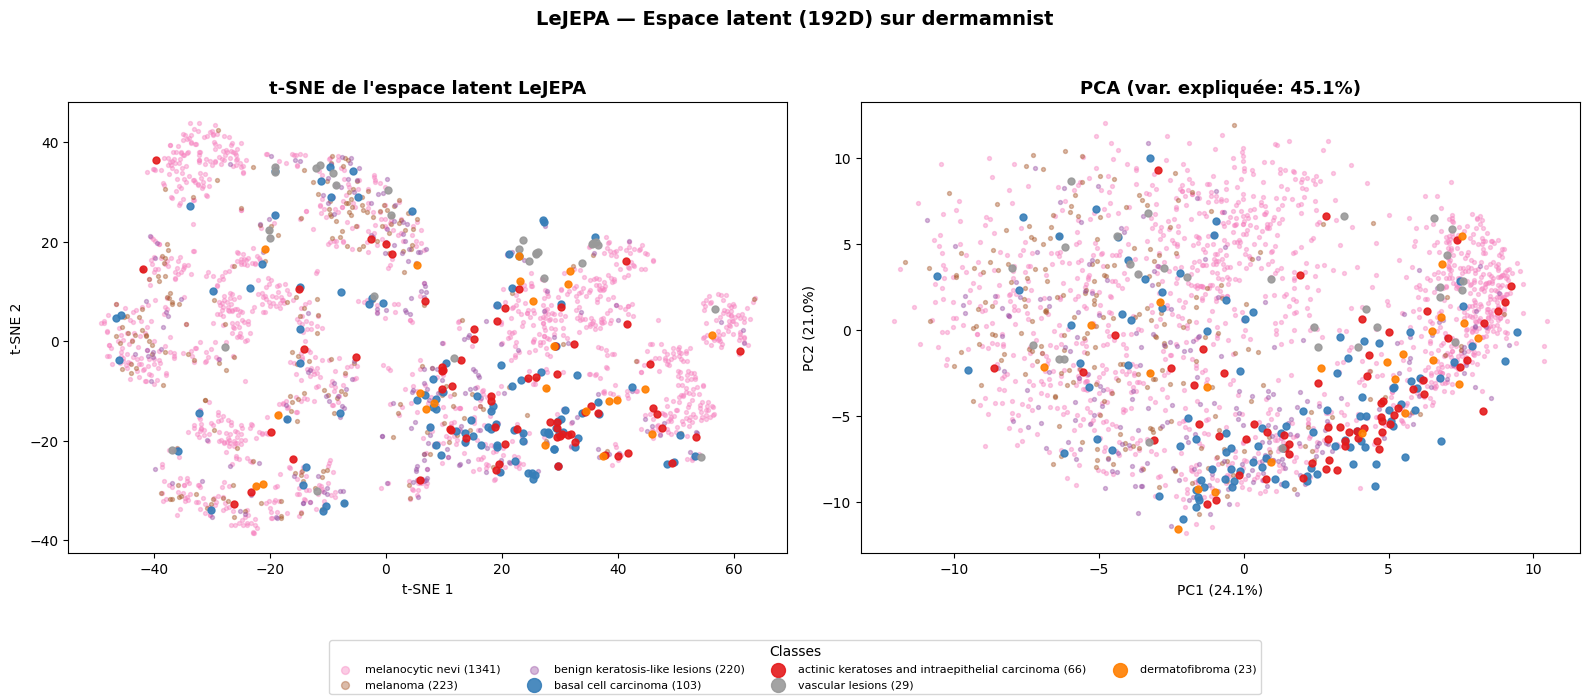

In [24]:
# Sous-échantillonnage pour la visualisation
n_viz = min(3000, len(test_features))
idx = np.random.choice(len(test_features), n_viz, replace=False)
viz_features = test_features[idx]
viz_labels = test_labels[idx]

# Noms des classes
class_names = list(info["label"].values())

# Couleurs bien distinctes pour chaque classe
colors = plt.cm.Set1(np.linspace(0, 1, n_classes))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# === t-SNE ===
print("Computing t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
tsne_coords = tsne.fit_transform(viz_features)

# === PCA ===
print("Computing PCA...")
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(viz_features)

# Tracer classe par classe, les classes MAJORITAIRES EN PREMIER (donc en dessous)
class_counts = np.bincount(viz_labels.astype(int), minlength=n_classes)
class_order = np.argsort(class_counts)[::-1]  # Du plus fréquent au plus rare

for c in class_order:
    mask = viz_labels == c
    n_samples = mask.sum()
    # Points plus gros et plus opaques pour les classes rares
    size = 8 if n_samples > 200 else 25
    alpha = 0.4 if n_samples > 200 else 0.9
    
    axes[0].scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                    color=colors[c], s=size, alpha=alpha, label=f"{class_names[c]} ({n_samples})")
    axes[1].scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                    color=colors[c], s=size, alpha=alpha, label=f"{class_names[c]} ({n_samples})")

axes[0].set_title("t-SNE de l'espace latent LeJEPA", fontsize=13, fontweight="bold")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

axes[1].set_title(f"PCA (var. expliquée: {pca.explained_variance_ratio_.sum():.1%})", 
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

# Légende commune en dessous
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, 
           markerscale=2, title="Classes")

plt.suptitle(f"LeJEPA — Espace latent ({EMBED_DIM}D) sur {DATASET_NAME}", 
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.show()

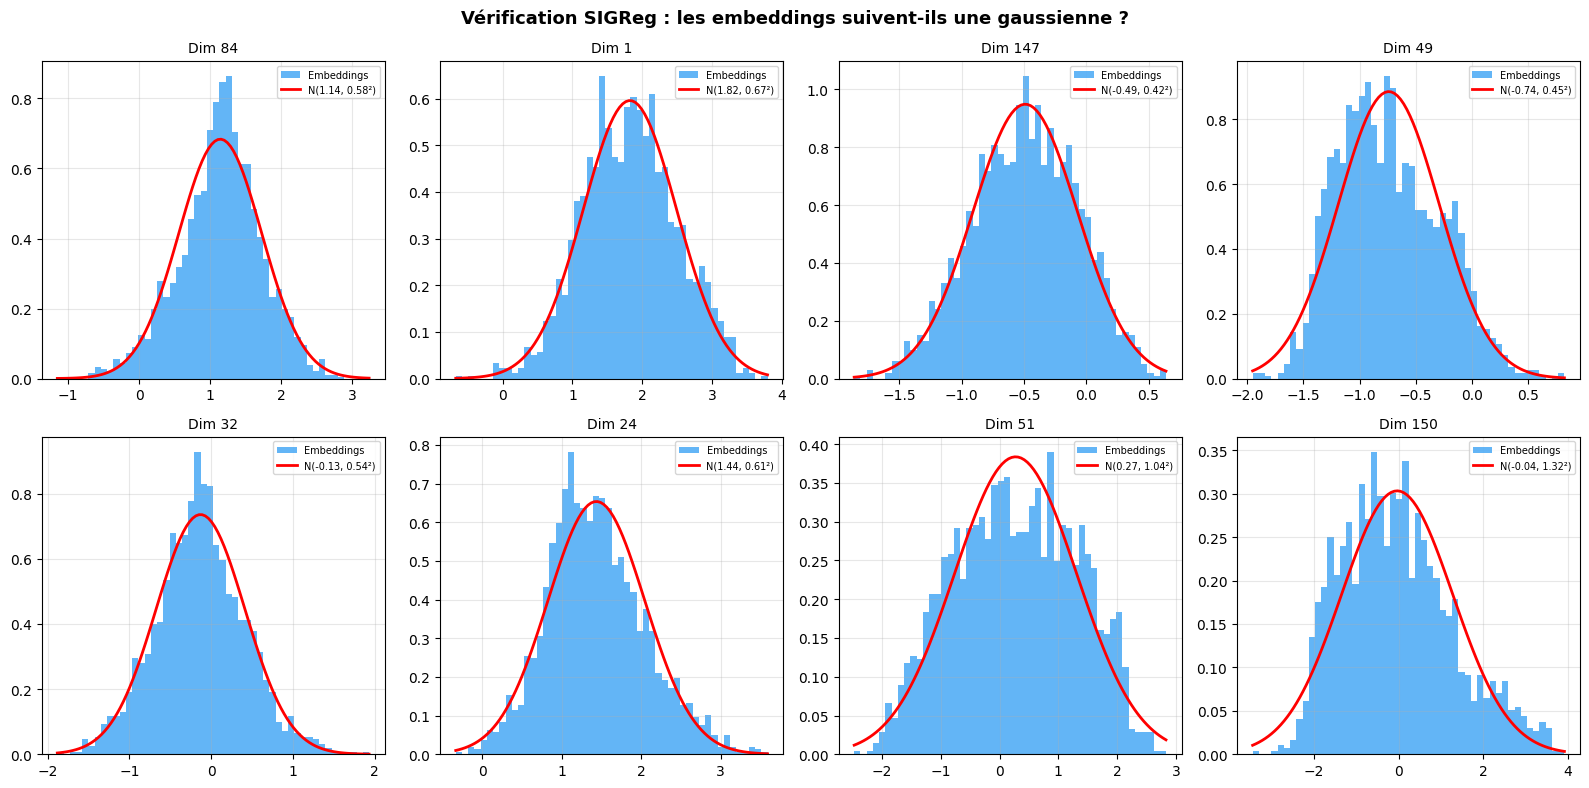


📊 Statistiques de l'espace latent:
   Moyenne par dim:    0.0031 (idéal: 0)
   Écart-type par dim: 0.7617 (idéal: 1)
   Min/Max:            [-5.95, 5.58]
   Corrélation inter-dim moyenne: 0.2823 (idéal: 0)


In [19]:
# === Vérification de la gaussianité des embeddings (validation de SIGReg) ===

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Histogrammes de 8 dimensions aléatoires
dims_to_plot = np.random.choice(EMBED_DIM, 8, replace=False)

for idx, (ax, dim) in enumerate(zip(axes.flat, dims_to_plot)):
    values = test_features[:, dim]
    
    # Histogramme des embeddings
    ax.hist(values, bins=50, density=True, alpha=0.7, color="#2196F3", label="Embeddings")
    
    # Courbe gaussienne théorique N(μ, σ²)
    mu, sigma = values.mean(), values.std()
    x_range = np.linspace(values.min(), values.max(), 100)
    gaussian = np.exp(-0.5 * ((x_range - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    ax.plot(x_range, gaussian, "r-", linewidth=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
    
    ax.set_title(f"Dim {dim}", fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Vérification SIGReg : les embeddings suivent-ils une gaussienne ?", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Statistiques globales
print("\n📊 Statistiques de l'espace latent:")
print(f"   Moyenne par dim:    {test_features.mean(axis=0).mean():.4f} (idéal: 0)")
print(f"   Écart-type par dim: {test_features.std(axis=0).mean():.4f} (idéal: 1)")
print(f"   Min/Max:            [{test_features.min():.2f}, {test_features.max():.2f}]")

# Matrice de corrélation (devrait être ~identité pour N(0, I_D))
corr = np.corrcoef(test_features.T)
off_diag = corr[np.triu_indices_from(corr, k=1)]
print(f"   Corrélation inter-dim moyenne: {np.abs(off_diag).mean():.4f} (idéal: 0)")

## 9. Sauvegarde du modèle

In [ ]:
# Sauvegarde
save_path = f"lejepa_{DATASET_NAME}_{IMAGE_SIZE}_ep{NUM_EPOCHS}.pt"

torch.save({
    "epoch": NUM_EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
    "config": {
        "dataset": DATASET_NAME,
        "image_size": IMAGE_SIZE,
        "embed_dim": EMBED_DIM,
        "patch_size": PATCH_SIZE,
        "num_heads": NUM_HEADS,
        "num_layers": NUM_LAYERS,
        "lambda_sigreg": LAMBDA_SIGREG,
        "num_slices": NUM_SLICES,
    },
    "test_accuracy": test_acc,
}, save_path)

print(f"💾 Modèle sauvegardé: {save_path}")
print(f"   Taille: {os.path.getsize(save_path) / 1e6:.1f} MB")

## 10. Bonus : Détection d'anomalies par distance à la gaussienne

Puisque SIGReg force les embeddings vers $\mathcal{N}(0, I_D)$, on peut détecter des images "anormales" en mesurant leur distance de Mahalanobis à cette distribution. C'est un sous-produit gratuit de l'entraînement !

Mahalanobis:   0%|          | 0/2005 [00:00<?, ?it/s]

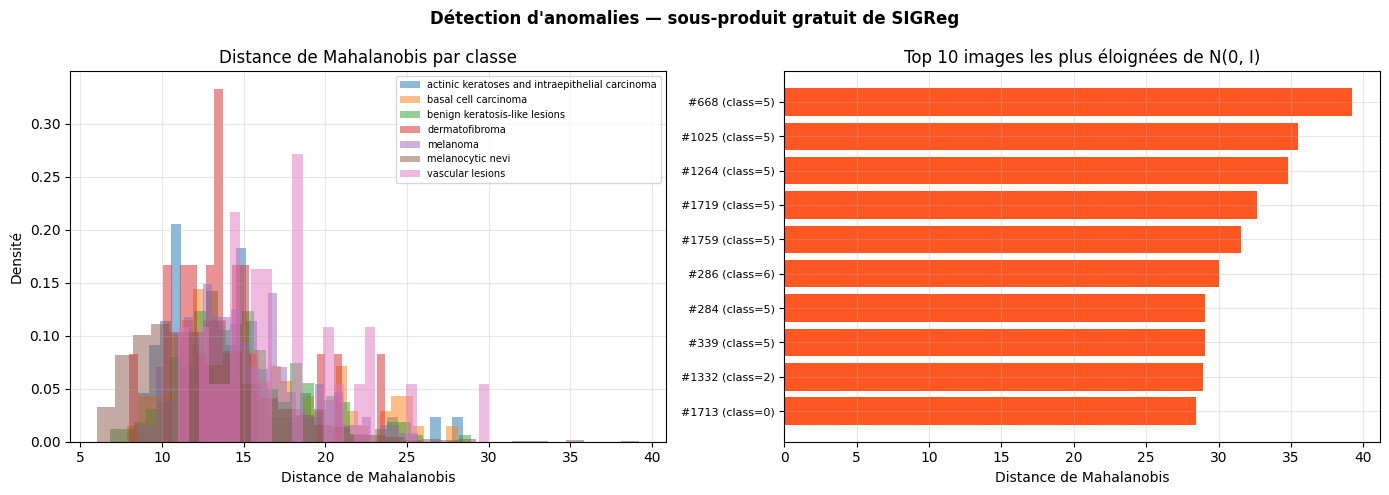


📊 Statistiques de distance:
   Moyenne: 13.34
   Médiane: 12.74
   Max:     39.19


In [20]:
from scipy.spatial.distance import mahalanobis

# Calculer la matrice de covariance des embeddings d'entraînement
train_mean = train_features.mean(axis=0)
train_cov = np.cov(train_features.T) + 1e-6 * np.eye(EMBED_DIM)  # Régularisation
train_cov_inv = np.linalg.inv(train_cov)

# Distance de Mahalanobis pour chaque image test
mahal_distances = np.array([
    mahalanobis(f, train_mean, train_cov_inv) 
    for f in tqdm(test_features, desc="Mahalanobis", leave=False)
])

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des distances par classe
for c in range(min(n_classes, 10)):
    mask = test_labels == c
    axes[0].hist(mahal_distances[mask], bins=30, alpha=0.5, 
                 label=class_names[c], density=True)

axes[0].set_title("Distance de Mahalanobis par classe")
axes[0].set_xlabel("Distance de Mahalanobis")
axes[0].set_ylabel("Densité")
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# Top 10 des images les plus "anormales"
top_anomaly_idx = np.argsort(mahal_distances)[-10:]
axes[1].barh(range(10), mahal_distances[top_anomaly_idx], color="#FF5722")
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f"#{i} (class={test_labels[i]})" for i in top_anomaly_idx], fontsize=8)
axes[1].set_title("Top 10 images les plus éloignées de N(0, I)")
axes[1].set_xlabel("Distance de Mahalanobis")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Détection d'anomalies — sous-produit gratuit de SIGReg", fontweight="bold")
plt.tight_layout()
plt.show()

print("\n📊 Statistiques de distance:")
print(f"   Moyenne: {mahal_distances.mean():.2f}")
print(f"   Médiane: {np.median(mahal_distances):.2f}")
print(f"   Max:     {mahal_distances.max():.2f}")

---

## 🎓 Pour aller plus loin

### Améliorations à tester :
1. **Résolution supérieure** : passer à MedMNIST+ 64×64 ou 128×128 (`IMAGE_SIZE = 64`)
2. **Autres datasets** : changer `DATASET_NAME` pour `dermamnist`, `bloodmnist`, etc.
3. **Architecture plus grande** : augmenter `NUM_LAYERS` et `EMBED_DIM`
4. **Fine-tuning** : dégeler l'encodeur et fine-tuner end-to-end sur une tâche
5. **World model** : ajouter un prédicteur de dynamique temporelle (si données séquentielles)

### Liens utiles :
- [Code officiel LeJEPA](https://github.com/galilai-group/lejepa)
- [Code officiel LeWorldModel](https://le-wm.github.io/)
- [Paper SIGReg (arXiv 2511.08544)](https://arxiv.org/abs/2511.08544)
- [MedMNIST](https://medmnist.com/)